In [151]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Bidirectional


In [153]:

file_path = 'nflx_2014_2023.csv'  
data = pd.read_csv(file_path)
data['date'] = pd.to_datetime(data['date'])
data.set_index('date', inplace=True)
print(data.head())


                 open       high        low      close    volume      rsi_7  \
date                                                                          
2014-01-02  52.401428  52.511429  51.542858  51.831429  12325600  34.729664   
2014-01-03  52.000000  52.495712  51.842857  51.871429  10817100  35.587886   
2014-01-06  51.889999  52.044285  50.475716  51.367142  15501500  29.820674   
2014-01-07  49.684284  49.698570  48.152859  48.500000  36167600  14.371863   
2014-01-08  48.104286  49.425713  48.074287  48.712856  20001100  18.049045   

               rsi_14       cci_7      cci_14     sma_50     ema_50  \
date                                                                  
2014-01-02  49.183584  -89.573201 -131.288579  50.112828  50.235157   
2014-01-03  49.457208  -65.820581 -103.026189  50.228771  50.299327   
2014-01-06  46.087900 -121.472559 -139.640566  50.312571  50.341203   
2014-01-07  32.522091 -206.762171 -238.029120  50.336228  50.268997   
2014-01-08  34.07354

In [155]:

data = data[['close']]  

data.rename(columns={'close': 'close (USD)'}, inplace=True)
print(data)


            close (USD)
date                   
2014-01-02    51.831429
2014-01-03    51.871429
2014-01-06    51.367142
2014-01-07    48.500000
2014-01-08    48.712856
...                 ...
2023-12-22   486.760010
2023-12-26   491.190002
2023-12-27   491.790009
2023-12-28   490.510010
2023-12-29   486.880005

[2516 rows x 1 columns]


In [157]:
print(data.isnull().sum())
data.dropna(inplace=True)

close (USD)    0
dtype: int64


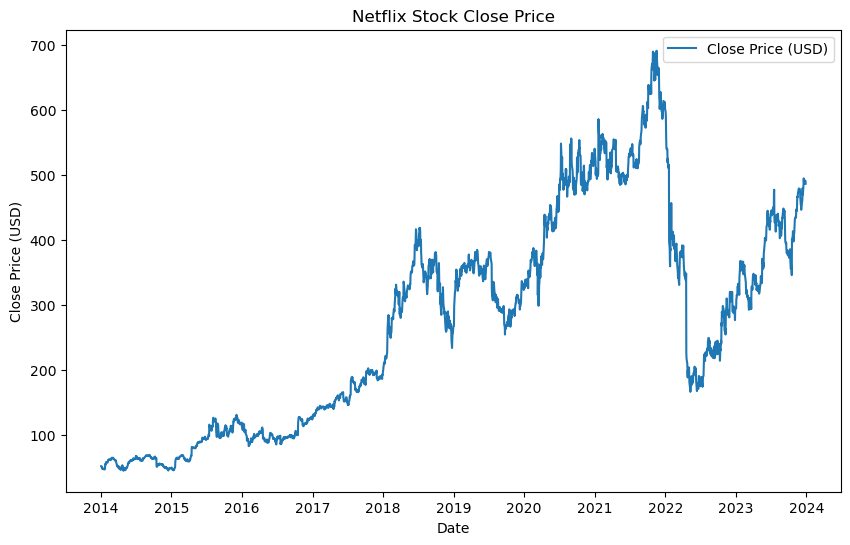

In [159]:

plt.figure(figsize=(10, 6))
plt.plot(data, label='Close Price (USD)')
plt.title('Netflix Stock Close Price')
plt.xlabel('Date')
plt.ylabel('Close Price (USD)')
plt.legend()
plt.show()

In [161]:

scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data)


In [163]:

def create_sequences(data, sequence_length):
    X, y = [], []
    for i in range(sequence_length, len(data)):
        X.append(data[i-sequence_length:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

sequence_length = 60 
X, y = create_sequences(data_scaled, sequence_length)


In [165]:

dates = data.index[sequence_length:]
split_date = '2021-01-01'  
train_idx = dates < split_date
test_idx = dates >= split_date

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]


In [167]:

X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

In [169]:

lstm_model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], 1)),
    LSTM(50, return_sequences=False),
    Dense(25),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mean_squared_error')

C:\Users\ACER\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [171]:

history = lstm_model.fit(X_train, y_train, batch_size=32, epochs=20, validation_data=(X_test, y_test), verbose=1)


Epoch 1/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 8s 54ms/step - loss: 0.0345 - val_loss: 0.0023
Epoch 2/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - loss: 7.3506e-04 - val_loss: 0.0022
Epoch 3/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - loss: 6.0329e-04 - val_loss: 0.0019
Epoch 4/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - loss: 5.0054e-04 - val_loss: 0.0018
Epoch 5/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - loss: 4.9484e-04 - val_loss: 0.0018
Epoch 6/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - loss: 5.2290e-04 - val_loss: 0.0018
Epoch 7/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - loss: 4.4501e-04 - val_loss: 0.0016
Epoch 8/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - loss: 4.4313e-04 - val_loss: 0.0015
Epoch 9/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 4.9468e-04 - val_loss: 0.0014
Epoch 10/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - loss: 4.6863e-04 - val_loss: 0.0014
Epoch 11/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - loss: 3.9569e-04 - val_loss: 0.0014
Epoch 12/20
54/54 ━━━━━

In [173]:

predictions = lstm_model.predict(X_test)
predictions = scaler.inverse_transform(predictions.reshape(-1, 1))

y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))


24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step


In [175]:

mse = mean_squared_error(y_test_actual, predictions)
mae = mean_absolute_error(y_test_actual, predictions)
r2 = r2_score(y_test_actual, predictions)

print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")
print(f"R-Squared: {r2}")

Mean Squared Error: 430.9093683891325
Mean Absolute Error: 14.96090197704754
R-Squared: 0.9756917850619452


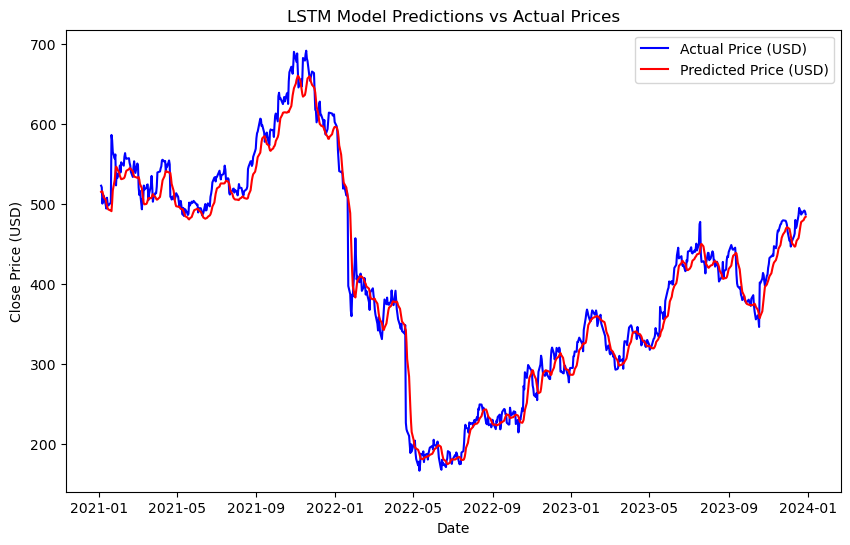

In [177]:

plt.figure(figsize=(10, 6))
plt.plot(dates[test_idx], y_test_actual, label='Actual Price (USD)', color='blue')
plt.plot(dates[test_idx], predictions, label='Predicted Price (USD)', color='red')
plt.title('LSTM Model Predictions vs Actual Prices')
plt.xlabel('Date')
plt.ylabel('Close Price (USD)')
plt.legend()
plt.show()

In [179]:

bi_lstm_model = Sequential([
    Bidirectional(LSTM(50, return_sequences=True), input_shape=(X_train.shape[1], 1)),
    Bidirectional(LSTM(50, return_sequences=False)),
    Dense(25),
    Dense(1)
])

bi_lstm_model.compile(optimizer='adam', loss='mean_squared_error')

C:\Users\ACER\anaconda3\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [181]:

bi_history = bi_lstm_model.fit(X_train, y_train, batch_size=32, epochs=20, validation_data=(X_test, y_test), verbose=1)


Epoch 1/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 12s 81ms/step - loss: 0.0194 - val_loss: 0.0059
Epoch 2/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - loss: 9.1384e-04 - val_loss: 0.0044
Epoch 3/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - loss: 5.7997e-04 - val_loss: 0.0020
Epoch 4/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 65ms/step - loss: 4.8227e-04 - val_loss: 0.0019
Epoch 5/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - loss: 3.9043e-04 - val_loss: 0.0013
Epoch 6/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - loss: 3.4765e-04 - val_loss: 9.6243e-04
Epoch 7/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - loss: 3.2073e-04 - val_loss: 9.2408e-04
Epoch 8/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - loss: 2.7725e-04 - val_loss: 0.0011
Epoch 9/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - loss: 2.9650e-04 - val_loss: 0.0015
Epoch 10/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - loss: 3.1085e-04 - val_loss: 8.4345e-04
Epoch 11/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 67ms/step - loss: 2.8217e-04 - val_loss: 7.3899e-04
Epoch 

In [183]:

bi_predictions = bi_lstm_model.predict(X_test)
bi_predictions = scaler.inverse_transform(bi_predictions.reshape(-1, 1))


24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step


In [185]:

bi_mse = mean_squared_error(y_test_actual, bi_predictions)
bi_mae = mean_absolute_error(y_test_actual, bi_predictions)
bi_r2 = r2_score(y_test_actual, bi_predictions)

print(f"Bi-LSTM Mean Squared Error: {bi_mse}")
print(f"Bi-LSTM Mean Absolute Error: {bi_mae}")
print(f"Bi-LSTM R-Squared: {bi_r2}")

Bi-LSTM Mean Squared Error: 247.5323189676984
Bi-LSTM Mean Absolute Error: 10.481931457505915
Bi-LSTM R-Squared: 0.9860363471880977


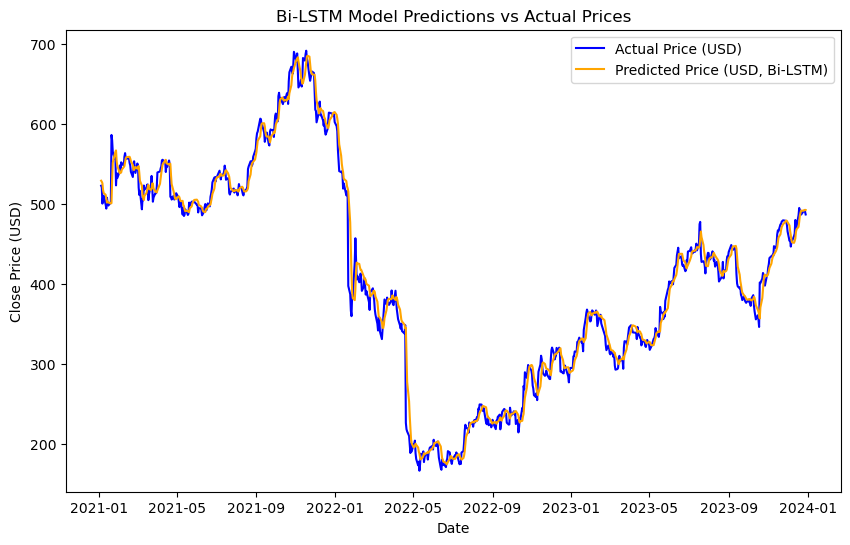

In [187]:

plt.figure(figsize=(10, 6))
plt.plot(dates[test_idx], y_test_actual, label='Actual Price (USD)', color='blue')
plt.plot(dates[test_idx], bi_predictions, label='Predicted Price (USD, Bi-LSTM)', color='orange')
plt.title('Bi-LSTM Model Predictions vs Actual Prices')
plt.xlabel('Date')
plt.ylabel('Close Price (USD)')
plt.legend()
plt.show()


In [275]:
import pyESN
from pyESN import ESN


In [277]:

scaler = MinMaxScaler(feature_range=(-1, 1))
close_prices['scaled_close'] = scaler.fit_transform(close_prices[['close']])



C:\Users\ACER\AppData\Local\Temp\ipykernel_11796\2622174522.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  close_prices['scaled_close'] = scaler.fit_transform(close_prices[['close']])


In [279]:
lookback = 30 
X, y = [], []
scaled_close = close_prices['scaled_close'].values
for i in range(lookback, len(scaled_close)):
    X.append(scaled_close[i-lookback:i])
    y.append(scaled_close[i])
X, y = np.array(X), np.array(y)

In [281]:
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]


In [283]:
n_inputs = lookback
n_outputs = 1
n_reservoir = 200
esn = ESN(n_inputs=n_inputs, n_outputs=n_outputs, n_reservoir=n_reservoir, random_state=42)


In [285]:
esn.fit(X_train, y_train)


array([[-1.01553   ],
       [-0.69086277],
       [-0.91593902],
       ...,
       [ 0.72379945],
       [ 0.6967852 ],
       [ 0.67267155]])

In [287]:
y_pred_scaled = esn.predict(X_test)


In [289]:
y_test_unscaled = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

In [291]:
y_test_unscaled = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
y_pred_unscaled = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()


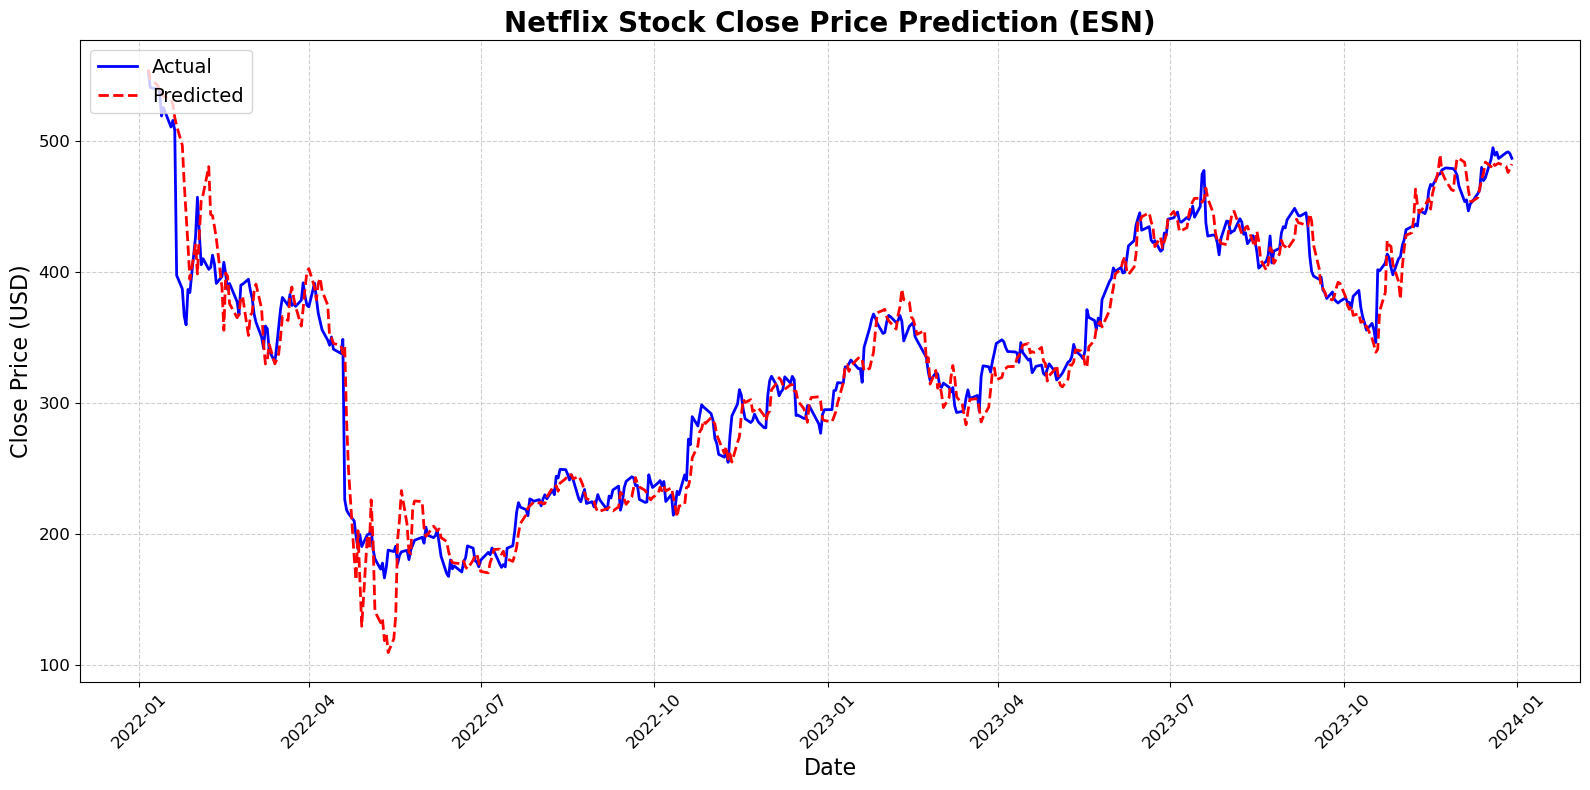

In [293]:
plt.figure(figsize=(16, 8))
plt.plot(close_prices['date'].iloc[-len(y_test):], y_test_unscaled, label='Actual', color='blue', linewidth=2)
plt.plot(close_prices['date'].iloc[-len(y_test):], y_pred_unscaled, label='Predicted', color='red', linestyle='--', linewidth=2)
plt.title('Netflix Stock Close Price Prediction (ESN)', fontsize=20, fontweight='bold')
plt.xlabel('Date', fontsize=16)
plt.ylabel('Close Price (USD)', fontsize=16)
plt.legend(fontsize=14, loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(fontsize=12, rotation=45)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()